# Perbandingan submission CatBoost v2 vs CatBoost–XGBoost blend

Notebook ini membandingkan:

- `submission_catboost_v2.csv`
- `output_blend/submission_blend_recent_fold.csv`

Perbandingan mencakup validitas file, continuity dari akhir data train,
kewajaran terhadap distribusi historis, smoothness, perbedaan per pos, dan
bukti rolling-origin OOF yang tersedia.

> **Batasan:** nilai TMA aktual pada periode test tidak tersedia. Karena itu,
> statistik submission dan grafik tidak dapat membuktikan akurasi test.
> Kesimpulan akurasi hanya boleh ditopang oleh validasi OOF atau skor
> leaderboard.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

TRAIN_PATH = Path("train.csv")
SAMPLE_PATH = Path("sample_submission.csv")
SUBMISSION_PATHS = {
    "CatBoost v2": Path("submission_catboost_v2.csv"),
    "Blend recent fold": Path("output_blend/submission_blend_recent_fold.csv"),
}
OOF_METRICS_PATH = Path("output_blend/fold_metrics.csv")
BLEND_SUMMARY_PATH = Path("output_blend/blend_summary.json")


def load_submission(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    required = {"id", "tma_mdpl"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{path}: kolom hilang {sorted(missing)}")
    frame = frame[["id", "tma_mdpl"]].copy()
    frame["datetime"] = pd.to_datetime(frame["id"].str[:19], errors="coerce")
    frame["nama_pos"] = frame["id"].str.split(" - ", n=1).str[1]
    if frame["datetime"].isna().any() or frame["nama_pos"].isna().any():
        raise ValueError(f"{path}: format id tidak valid")
    if frame["id"].duplicated().any():
        raise ValueError(f"{path}: id duplikat")
    if not np.isfinite(frame["tma_mdpl"]).all():
        raise ValueError(f"{path}: prediksi mengandung NaN/inf")
    return frame


train = pd.read_csv(TRAIN_PATH, parse_dates=["datetime"])
sample = pd.read_csv(SAMPLE_PATH)
submissions = {name: load_submission(path) for name, path in SUBMISSION_PATHS.items()}

for name, frame in submissions.items():
    if not frame["id"].equals(sample["id"]):
        raise ValueError(f"Urutan id {name} tidak cocok dengan sample_submission")

print(f"Train: {train.shape[0]:,} baris | {train['nama_pos'].nunique()} pos")
print(f"Periode train: {train['datetime'].min()} s.d. {train['datetime'].max()}")
for name, frame in submissions.items():
    print(
        f"{name}: {len(frame):,} baris | {frame['nama_pos'].nunique()} pos | "
        f"{frame['datetime'].min()} s.d. {frame['datetime'].max()}"
    )

Train: 84,396 baris | 30 pos
Periode train: 2023-01-01 06:00:00 s.d. 2025-09-18 18:00:00
CatBoost v2: 21,780 baris | 30 pos | 2025-09-19 06:00:00 s.d. 2026-05-18 18:00:00
Blend recent fold: 21,780 baris | 30 pos | 2025-09-19 06:00:00 s.d. 2026-05-18 18:00:00


## 1. Pemeriksaan kuantitatif tanpa label test

Metrik di bawah adalah **diagnostik kewajaran**, bukan ukuran akurasi test:

- `boundary_mae`: rata-rata perubahan absolut dari TMA aktual terakhir ke
  prediksi pertama.
- `outside_3iqr_pct`: persentase prediksi di luar Q1−3×IQR hingga Q3+3×IQR
  historis masing-masing pos.
- `outside_history_pct`: persentase di luar min–max historis.
- `step_change_mae`: rata-rata perubahan absolut antar-prediksi berurutan.

In [2]:
history = train.groupby("nama_pos")["tma_mdpl"].agg(
    hist_min="min",
    hist_max="max",
    hist_median="median",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
)
history["iqr"] = history["q3"] - history["q1"]

last_actual = (
    train.sort_values("datetime")
    .groupby("nama_pos", as_index=False)
    .tail(1)
    .set_index("nama_pos")["tma_mdpl"]
)

diagnostic_rows = []
boundary_by_model = {}

for name, frame in submissions.items():
    first_prediction = (
        frame.sort_values("datetime")
        .groupby("nama_pos", as_index=False)
        .head(1)
        .set_index("nama_pos")["tma_mdpl"]
    )
    boundary_jump = (first_prediction - last_actual).abs()
    boundary_by_model[name] = boundary_jump

    merged = frame.merge(history, left_on="nama_pos", right_index=True)
    outside_3iqr = (
        (merged["tma_mdpl"] < merged["q1"] - 3 * merged["iqr"])
        | (merged["tma_mdpl"] > merged["q3"] + 3 * merged["iqr"])
    )
    outside_history = (
        (merged["tma_mdpl"] < merged["hist_min"])
        | (merged["tma_mdpl"] > merged["hist_max"])
    )
    step_change = (
        frame.sort_values(["nama_pos", "datetime"])
        .groupby("nama_pos")["tma_mdpl"]
        .diff()
        .abs()
    )

    diagnostic_rows.append(
        {
            "submission": name,
            "pred_mean": frame["tma_mdpl"].mean(),
            "pred_std": frame["tma_mdpl"].std(),
            "pred_min": frame["tma_mdpl"].min(),
            "pred_max": frame["tma_mdpl"].max(),
            "boundary_mae": boundary_jump.mean(),
            "boundary_max": boundary_jump.max(),
            "outside_3iqr_pct": 100 * outside_3iqr.mean(),
            "outside_history_pct": 100 * outside_history.mean(),
            "step_change_mae": step_change.mean(),
        }
    )

diagnostics = pd.DataFrame(diagnostic_rows).set_index("submission")
display(diagnostics.round(6))

cat = submissions["CatBoost v2"]
blend = submissions["Blend recent fold"]
prediction_delta = blend["tma_mdpl"] - cat["tma_mdpl"]

pairwise = pd.Series(
    {
        "correlation": cat["tma_mdpl"].corr(blend["tma_mdpl"]),
        "prediction_difference_mae": prediction_delta.abs().mean(),
        "prediction_difference_rmse": np.sqrt(np.mean(prediction_delta**2)),
        "prediction_difference_p95_abs": prediction_delta.abs().quantile(0.95),
        "prediction_difference_max_abs": prediction_delta.abs().max(),
    },
    name="value",
)
display(pairwise.to_frame().round(6))

,pred_mean,pred_std,pred_min,pred_max,boundary_mae,boundary_max,outside_3iqr_pct,outside_history_pct,step_change_mae
submission,,,,,,,,,
CatBoost v2,55.302321,46.699402,0.758101,144.358223,0.311487,1.666869,0.105601,0.004591,0.080102
Blend recent fold,55.464639,46.751102,0.784048,144.750909,0.346920,1.601380,0.229568,0.238751,0.079109


,value
correlation,0.999967
prediction_difference_mae,0.240117
prediction_difference_rmse,0.418627
prediction_difference_p95_abs,0.802669
prediction_difference_max_abs,5.078617


## 2. Pos dengan perbedaan prediksi terbesar

,difference_mae,difference_rmse,difference_max_abs,mean_delta
nama_pos,,,,
Wonogiri Dam,1.468229,1.656344,5.078617,1.448952
Bojonegoro - Kali Kethek,0.444397,0.612287,1.635101,0.329882
Kali Anyar - Kreteg Abang,0.499514,0.569903,1.332854,0.497079
Ketonggo,0.323510,0.409757,1.119890,0.095540
Boboh Kali Lamong,0.301695,0.404531,1.073493,0.283742
Floodway Bridge C,0.314738,0.394764,1.015708,0.289392
Jurug,0.305501,0.392924,1.284837,0.024943
Napel,0.296964,0.379038,1.125266,0.180665
Colo Weir,0.252425,0.344385,1.065235,0.250084


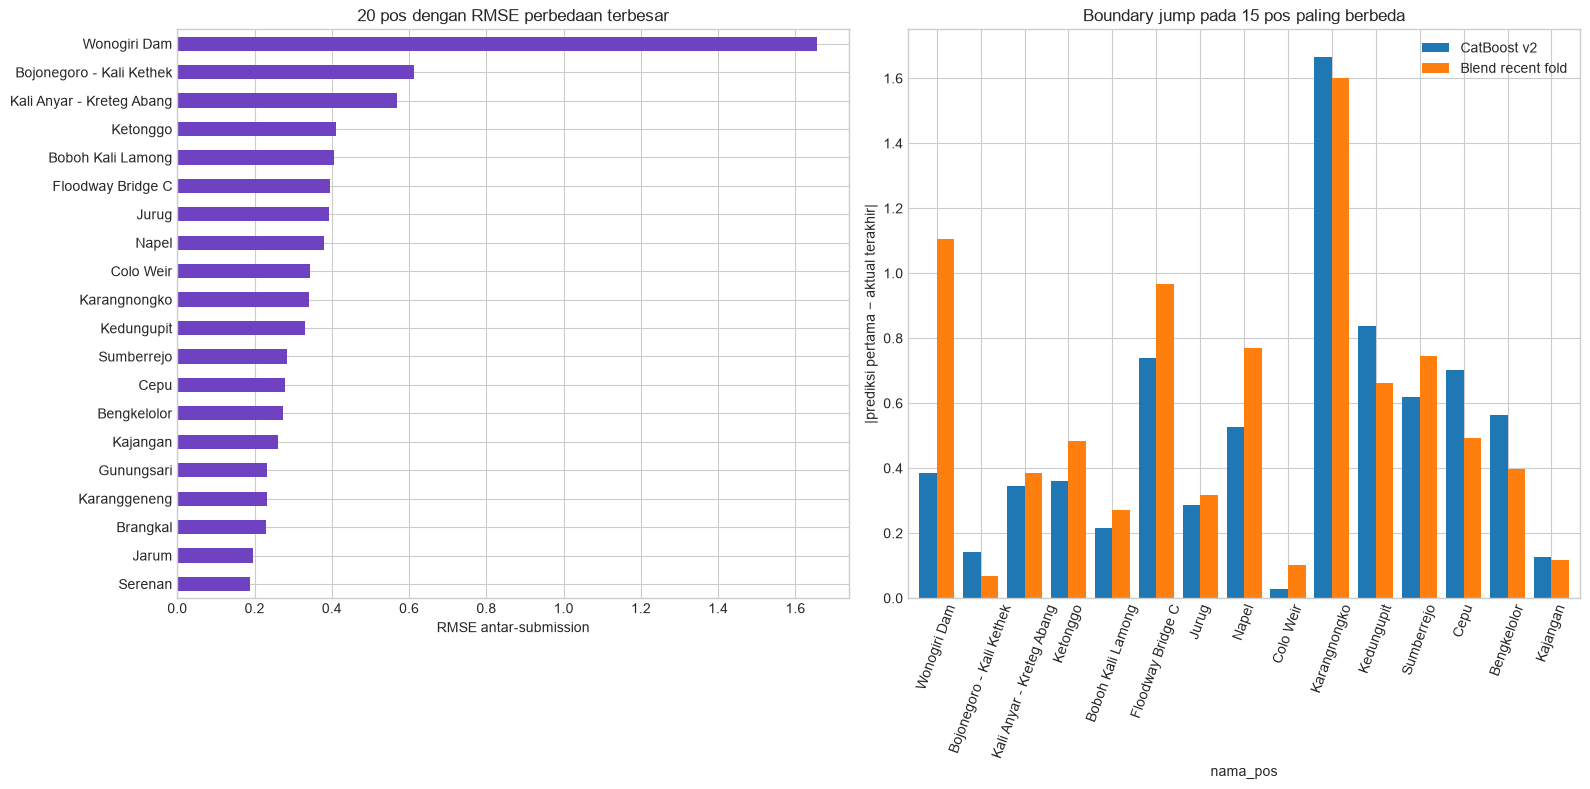

In [3]:
comparison = cat[["id", "datetime", "nama_pos", "tma_mdpl"]].rename(
    columns={"tma_mdpl": "pred_catboost_v2"}
)
comparison["pred_blend_recent"] = blend["tma_mdpl"].to_numpy()
comparison["delta"] = (
    comparison["pred_blend_recent"] - comparison["pred_catboost_v2"]
)

per_station = comparison.groupby("nama_pos").agg(
    difference_mae=("delta", lambda s: s.abs().mean()),
    difference_rmse=("delta", lambda s: np.sqrt(np.mean(s**2))),
    difference_max_abs=("delta", lambda s: s.abs().max()),
    mean_delta=("delta", "mean"),
)
per_station = per_station.sort_values("difference_rmse", ascending=False)
display(per_station.head(15).round(6))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
per_station.sort_values("difference_rmse").tail(20)["difference_rmse"].plot.barh(
    ax=axes[0], color="#6f42c1"
)
axes[0].set_title("20 pos dengan RMSE perbedaan terbesar")
axes[0].set_xlabel("RMSE antar-submission")
axes[0].set_ylabel("")

boundary_plot = pd.DataFrame(boundary_by_model)
boundary_plot.loc[per_station.head(15).index].plot.bar(ax=axes[1], width=0.8)
axes[1].set_title("Boundary jump pada 15 pos paling berbeda")
axes[1].set_ylabel("|prediksi pertama − aktual terakhir|")
axes[1].tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## 3. Overlay temporal pada pos paling berbeda

Grafik menampilkan 120 hari terakhir data aktual dan seluruh periode forecast.
Sumbu-Y memakai persentil 1%–99% gabungan agar outlier ekstrem tidak membuat
garis utama sulit dibaca.

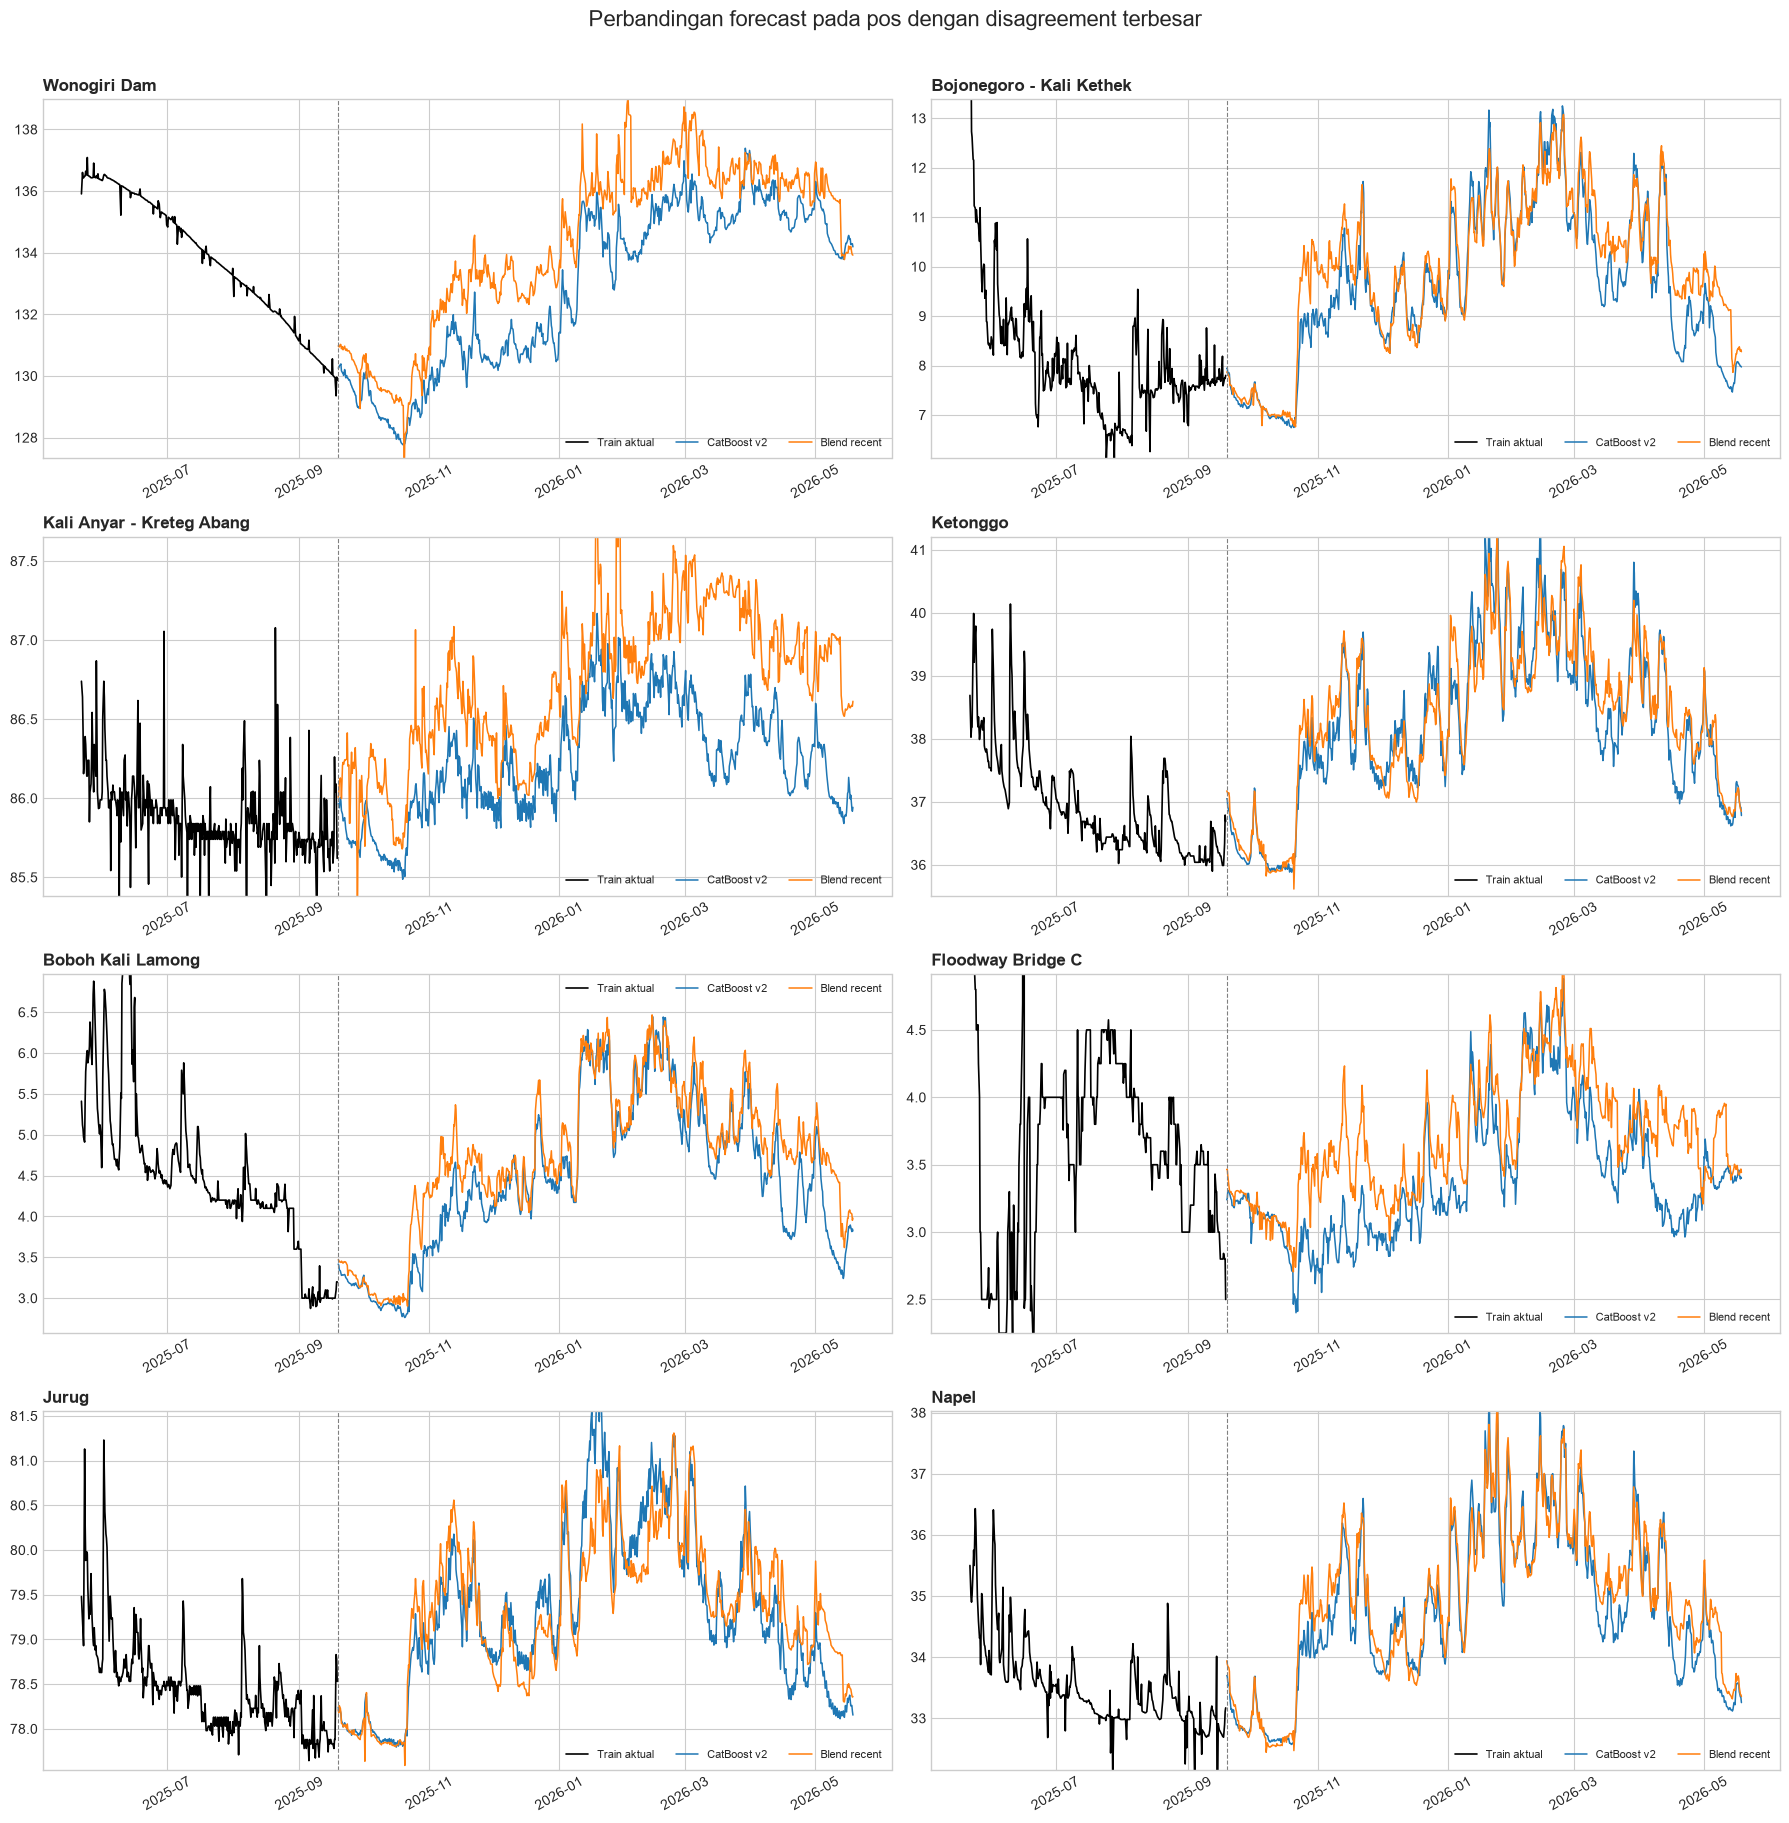

In [4]:
stations_to_plot = per_station.head(8).index.tolist()
history_start = train["datetime"].max() - pd.Timedelta(days=120)

fig, axes = plt.subplots(4, 2, figsize=(18, 18), squeeze=False)
for ax, station in zip(axes.ravel(), stations_to_plot):
    actual = train[
        (train["nama_pos"] == station) & (train["datetime"] >= history_start)
    ].sort_values("datetime")
    pred_cat = cat[cat["nama_pos"] == station].sort_values("datetime")
    pred_blend = blend[blend["nama_pos"] == station].sort_values("datetime")

    ax.plot(actual["datetime"], actual["tma_mdpl"], label="Train aktual", lw=1.2, color="black")
    ax.plot(pred_cat["datetime"], pred_cat["tma_mdpl"], label="CatBoost v2", lw=1.1)
    ax.plot(pred_blend["datetime"], pred_blend["tma_mdpl"], label="Blend recent", lw=1.1)
    ax.axvline(pred_cat["datetime"].min(), color="gray", ls="--", lw=0.8)

    combined = pd.concat(
        [actual["tma_mdpl"], pred_cat["tma_mdpl"], pred_blend["tma_mdpl"]]
    )
    lower, upper = combined.quantile([0.01, 0.99])
    margin = max((upper - lower) * 0.08, 0.1)
    ax.set_ylim(lower - margin, upper + margin)
    ax.set_title(station, loc="left", fontweight="bold")
    ax.legend(fontsize=8, ncol=3)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Perbandingan forecast pada pos dengan disagreement terbesar", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 4. Bukti validasi OOF dan kesimpulan

In [5]:
if not OOF_METRICS_PATH.exists() or not BLEND_SUMMARY_PATH.exists():
    raise FileNotFoundError("Artefak OOF blend tidak ditemukan di output_blend/")

oof_metrics = pd.read_csv(OOF_METRICS_PATH)
with BLEND_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    blend_summary = json.load(file)

recent_fold = blend_summary["recent_candidate_fold"]
recent_cat_rmse = blend_summary["recent_candidate_catboost_rmse"]
recent_blend_rmse = blend_summary["recent_candidate_blend_rmse"]
improvement_pct = 100 * (recent_cat_rmse - recent_blend_rmse) / recent_cat_rmse

oof_display = oof_metrics.rename(
    columns={"blend_rmse": "pooled_weight_blend_rmse"}
).copy()
oof_display["recent_candidate_blend_rmse"] = np.nan
oof_display.loc[
    oof_display["fold"] == recent_fold, "recent_candidate_blend_rmse"
] = recent_blend_rmse
display(oof_display.round(6))

cat_diag = diagnostics.loc["CatBoost v2"]
blend_diag = diagnostics.loc["Blend recent fold"]

conclusion = f'''
### Kesimpulan

**Pilihan yang lebih menjanjikan untuk eksperimen leaderboard adalah
`submission_blend_recent_fold.csv`.**

Alasannya:

1. Pada fold terbaru `{recent_fold}` yang musim dan ukuran training-nya paling
   mendekati test, blend menurunkan RMSE dari **{recent_cat_rmse:.6f}** menjadi
   **{recent_blend_rmse:.6f}** atau membaik **{improvement_pct:.2f}%**.
2. Bobotnya dipilih dari OOF prediction, bukan dari pola submission test:
   **{100 * blend_summary['recent_candidate_catboost_weight']:.2f}% CatBoost +
   {100 * blend_summary['recent_candidate_xgboost_weight']:.2f}% XGBoost**.
3. Kedua submission sangat mirip (korelasi
   **{pairwise['correlation']:.6f}**), sehingga blend masih berada dekat dengan
   solusi CatBoost.

Namun, **CatBoost v2 adalah pilihan lebih konservatif** secara diagnostik:
boundary MAE-nya {cat_diag['boundary_mae']:.4f} dibanding
{blend_diag['boundary_mae']:.4f}, dan proporsi di luar rentang historis
{cat_diag['outside_history_pct']:.4f}% dibanding
{blend_diag['outside_history_pct']:.4f}%.

Catatan penting: OOF di atas membandingkan blend dengan CatBoost component dari
pipeline blend baru, **bukan model persis yang menghasilkan
`submission_catboost_v2.csv`**. Artefak OOF untuk file CatBoost v2 lama tidak
tersedia. Karena itu, keputusan final yang benar-benar definitif hanya dapat
dibuat setelah membandingkan skor leaderboard kedua file.
'''
display(Markdown(conclusion))

,fold,n_validation,catboost_rmse,xgboost_rmse,pooled_weight_blend_rmse,catboost_mae,xgboost_mae,blend_mae,fold_optimal_catboost_weight,catboost_best_iteration,xgboost_best_iteration,recent_candidate_blend_rmse
0,sep_2023,20696,2.686667,2.935736,2.686667,0.771388,1.106144,0.771388,1.000000,262,2,NaN
1,sep_2024,19514,1.237670,1.322525,1.237670,0.610577,0.677589,0.610577,0.653217,1374,151,1.202734



### Kesimpulan

**Pilihan yang lebih menjanjikan untuk eksperimen leaderboard adalah
`submission_blend_recent_fold.csv`.**

Alasannya:

1. Pada fold terbaru `sep_2024` yang musim dan ukuran training-nya paling
   mendekati test, blend menurunkan RMSE dari **1.237670** menjadi
   **1.202734** atau membaik **2.82%**.
2. Bobotnya dipilih dari OOF prediction, bukan dari pola submission test:
   **65.32% CatBoost +
   34.68% XGBoost**.
3. Kedua submission sangat mirip (korelasi
   **0.999967**), sehingga blend masih berada dekat dengan
   solusi CatBoost.

Namun, **CatBoost v2 adalah pilihan lebih konservatif** secara diagnostik:
boundary MAE-nya 0.3115 dibanding
0.3469, dan proporsi di luar rentang historis
0.0046% dibanding
0.2388%.

Catatan penting: OOF di atas membandingkan blend dengan CatBoost component dari
pipeline blend baru, **bukan model persis yang menghasilkan
`submission_catboost_v2.csv`**. Artefak OOF untuk file CatBoost v2 lama tidak
tersedia. Karena itu, keputusan final yang benar-benar definitif hanya dapat
dibuat setelah membandingkan skor leaderboard kedua file.
